This is a script that calculates the vT contours and the Ocean Heat Content for NorESM2-LM, IPSL-CM6A-LR and CESM2.

### **0. Importing packages and functions**

In [1]:
# Importing extra packages
from dask.diagnostics import ProgressBar
import warnings
warnings.simplefilter("ignore")
# for skiping running a certain cell
from IPython.core.magic import register_cell_magic

@register_cell_magic
def comment(line, cell):
    return

# for getting ot the right directory
import sys

#importing the necessary functions
sys.path.append("/nird/home/chrikap/Atmosphere_Ocean_Interactions_PhD/functions/nird_functions")
from ocean_functions import*
from common_NIRD_functions import*
from matplotlib.ticker import FuncFormatter

# **A. NorESM2-LM**

## **1. Getting the data from NIRD**

### **1.1. meridional velocity (vo)**

In [2]:
experiments = ['piControl', 'abrupt-4xCO2']

vo_piControl_noresm2 = []
vo_x4CO2_noresm2 = []

for experiment in experiments:
            
    folder_path = f'/projects/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/{experiment}/r1i1p1f1/Omon/vo/gr/latest/'

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks={'time': 12}) for file_name in file_names if file_name.endswith('.nc')]
    
    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(0, 500*12))

    if experiment == 'piControl':
    
        vo_piControl_noresm2 =  ds 
    else: 
        vo_x4CO2_noresm2 =  ds 

### **1.2. potential temperature (thetao)**

!!Careful in that it's in C!!

In [3]:
experiments = ['piControl', 'abrupt-4xCO2']

thetao_piControl_noresm2 = []
thetao_x4CO2_noresm2 = []

for experiment in experiments:
            
    folder_path = f'/projects/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/{experiment}/r1i1p1f1/Omon/thetao/gr/latest/'

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks={'time': 12}) for file_name in file_names if file_name.endswith('.nc')]
    
    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')

    ds = merged_datasets.isel(time=slice(0, 500*12))
    
    if experiment == 'piControl':
    
        thetao_piControl_noresm2 =  ds  
    else: 
        thetao_x4CO2_noresm2 =  ds  

**Temperature does not need to be turned from C --> K!!!**

See: https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2008jc005190

### **2. Calculating the total vT contours**

#### **2.1. Calculate v*T**

In [4]:
# Align first 
vo_piControl_noresm2, thetao_piControl_noresm2 = xr.align(vo_piControl_noresm2, thetao_piControl_noresm2, join="exact")  # T in deg C
vo_x4CO2_noresm2, thetao_x4CO2_noresm2 = xr.align(vo_x4CO2_noresm2, thetao_x4CO2_noresm2, join="exact")

# Multiply the two variables
vT_pi_noresm2 = vo_piControl_noresm2["vo"] * thetao_piControl_noresm2["thetao"]    # T in deg C
vT_x4_noresm2 = vo_x4CO2_noresm2["vo"] * thetao_x4CO2_noresm2["thetao"]

# Create a new Dataset including the shared variables (piControl)
vT_pi_noresm2_ds = xr.Dataset(
    data_vars={
        "vT": vT_pi_noresm2,
        "time_bnds": vo_piControl_noresm2["time_bnds"],
        "lev_bnds": vo_piControl_noresm2["lev_bnds"],
        "vertices_latitude": vo_piControl_noresm2["vertices_latitude"],
        "vertices_longitude": vo_piControl_noresm2["vertices_longitude"],
    },
    coords={
        "time": vo_piControl_noresm2["time"],
        "lev": vo_piControl_noresm2["lev"],
        "j": vo_piControl_noresm2["j"],
        "i": vo_piControl_noresm2["i"],
        "latitude": vo_piControl_noresm2["latitude"],
        "longitude": vo_piControl_noresm2["longitude"],
    },
    attrs=vo_piControl_noresm2.attrs 
)

# Create a new Dataset including the shared variables (x4CO2)
vT_x4_noresm2_ds = xr.Dataset(
    data_vars={
        "vT": vT_x4_noresm2,
        "time_bnds": vo_x4CO2_noresm2["time_bnds"],
        "lev_bnds": vo_x4CO2_noresm2["lev_bnds"],
        "vertices_latitude": vo_x4CO2_noresm2["vertices_latitude"],
        "vertices_longitude": vo_x4CO2_noresm2["vertices_longitude"],
    },
    coords={
        "time": vo_x4CO2_noresm2["time"],
        "lev": vo_x4CO2_noresm2["lev"],
        "j": vo_x4CO2_noresm2["j"],
        "i": vo_x4CO2_noresm2["i"],
        "latitude": vo_x4CO2_noresm2["latitude"],
        "longitude": vo_x4CO2_noresm2["longitude"],
    },
    attrs=vo_x4CO2_noresm2.attrs  # optional: copy global attributes
)

#### **2.2. Time average (try with yearly_avg now)**

In [5]:
#piControl
vT_y_pi_noresm2 = yearly_avg_nan_proof(vT_pi_noresm2_ds) #first weighted average to make months -> years
vT_0_30_pi_noresm2 = vT_y_pi_noresm2.isel(year=slice(0, 30)).mean(dim='year', skipna = True)
#x4CO2 - the 470-500 time slice
vT_y_x4_noresm2 = yearly_avg_nan_proof(vT_x4_noresm2_ds)
vT_470_500_x4_noresm2 = vT_y_x4_noresm2.isel(year=slice(470, 500)).mean(dim='year', skipna = True)

#### **3.3. Regrid**

In [6]:
#piControl
vT_pi_noresm2_renamed = consistent_naming(vT_0_30_pi_noresm2)
vT_pi_noresm2_regr = regrid_ocean_conserv(vT_pi_noresm2_renamed, "vT", None)
#x4CO2
vT_470_500_x4_noresm2_renamed = consistent_naming(vT_470_500_x4_noresm2)
vT_470_500_x4_noresm2_regr = regrid_ocean_conserv(vT_470_500_x4_noresm2_renamed, "vT", None)

In regrid_file
Regridding maker made
Regridding completed
In regrid_file
Regridding maker made
Regridding completed


#### **2.4. Zonal mean**

In [8]:
#piControl
vT_pi_noresm2_regr_zonal = vT_pi_noresm2_regr.mean(dim='lon', skipna = True)
#x4CO2
vT_470_500_x4_noresm2_regr_zonal = vT_470_500_x4_noresm2_regr.mean(dim='lon', skipna = True)

#### **2.5. Calculating the values and saving**

In [9]:
vT_pi_noresm2_regr_zonal_v = vT_pi_noresm2_regr_zonal['vT'].values

vT_470_500_x4_noresm2_regr_zonal_v = vT_470_500_x4_noresm2_regr_zonal['vT'].values

lat_noresm2 = vT_pi_noresm2_regr_zonal['lat'].values
lev_noresm2 = vT_pi_noresm2_regr_zonal['lev'].values

In [11]:
save_dir = '/nird/home/chrikap/data/v_T_data/04.03.2026'
#
f_vT_pi_noresm2_regr_zonal_v = f"{save_dir}/vT_pi_noresm2_regr_zonal_v.npy"
f_vT_470_500_x4_noresm2_regr_zonal_v = f"{save_dir}/vT_470_500_x4_noresm2_regr_zonal_v.npy"

f_lat_noresm2 = f"{save_dir}/lat_noresm2.npy"
f_lev_noresm2 = f"{save_dir}/lev_noresm2.npy"

np.save(f_vT_pi_noresm2_regr_zonal_v, vT_pi_noresm2_regr_zonal_v)
np.save(f_vT_470_500_x4_noresm2_regr_zonal_v, vT_470_500_x4_noresm2_regr_zonal_v)

np.save(f_lat_noresm2, lat_noresm2)
np.save(f_lev_noresm2, lev_noresm2)

#### **2.6. Checking if the depth-cumlat integral gives the heat transport**

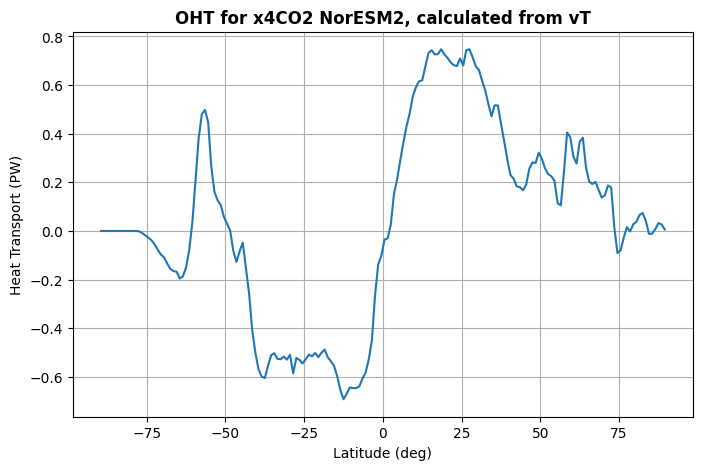

In [111]:
depth = lev_noresm2
lat = lat_noresm2

rho = 1025.0  # kg/m3
cp = 3985.0   # J/(kg·K)
R_earth = 6371000.0  # Earth radius in meters

# 1. Compute layer thicknesses
dz = np.diff(depth, prepend=0.0)  # shape: (depth,)

# 2. Broadcast to match (depth, lat)
dz_2d = dz[:, np.newaxis]  # shape: (depth, 1)

# 3. Multiply by layer thickness and sum over depth, ignoring NaNs (depth-integrated meridional flux)
vT_depth_integrated = np.sum(vT_470_500_x4_noresm2_regr_zonal_v * dz_2d, axis=0)  # shape: (lat,)

# 4. Zonal length at each latitude
lat_rad = np.deg2rad(lat)
zonal_length = 2 * np.pi * R_earth * np.cos(lat_rad)  # meters

# 5. Total meridional heat transport
Q_phi = vT_depth_integrated * rho * cp * zonal_length  # shape: (lat,)

plt.figure(figsize=(8,5))
plt.plot(lat, Q_phi / 1e15)
plt.xlabel('Latitude (deg)')
plt.ylabel('Heat Transport (PW)')
plt.title('OHT for x4CO2 NorESM2, calculated from vT', fontweight = 'bold')
plt.grid()
#plt.legend()
plt.show()

#### **7. Calculating the anomalies**

In [12]:
anom_noresm2 = vT_470_500_x4_noresm2_regr_zonal_v - vT_pi_noresm2_regr_zonal_v

In [ ]:
# check: Depth and cumz integrate both x4CO2 and the anomalies

# subtract from the x4co2 curves the picontrol curve and compare this to the anomaly curves as well. 

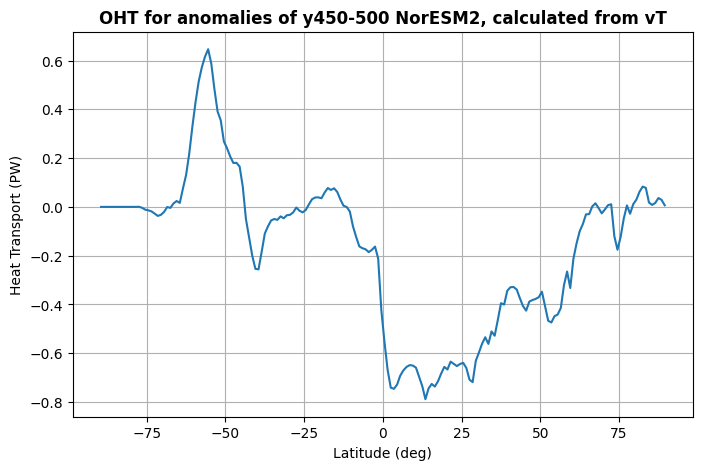

In [15]:
# 1. Calculating the anomaly curve from the anomaly plot and comparing with the anomaly OHT curves from hfbasin.

# 5. Checking if the depth-cumlat integral gives the heat transport

depth = lev_noresm2
lat = lat_noresm2

rho = 1025.0  # kg/m3
cp = 3985.0   # J/(kg·K)
R_earth = 6371000.0  # Earth radius in meters

# -----------------------------
# STEP 1: compute layer thicknesses
# -----------------------------
# Assuming depth array is midpoints
dz = np.diff(depth, prepend=0.0)  # shape: (depth,)

# Broadcast to match (depth, lat)
dz_2d = dz[:, np.newaxis]  # shape: (depth, 1)

# -----------------------------
# STEP 2: depth-integrated meridional flux
# -----------------------------
# Multiply by layer thickness and sum over depth, ignoring NaNs
vT_depth_integrated = np.nansum(anom_noresm2 * dz_2d, axis=0)  # shape: (lat,)

# -----------------------------
# STEP 3: convert to meridional heat transport (Watts)
# -----------------------------
# Zonal length at each latitude
lat_rad = np.deg2rad(lat)
zonal_length = 2 * np.pi * R_earth * np.cos(lat_rad)  # meters

# Total meridional heat transport
Q_phi_x4 = vT_depth_integrated * rho * cp * zonal_length  # shape: (lat,)
# -----------------------------

plt.figure(figsize=(8,5))
plt.plot(lat, Q_phi_x4 / 1e15)
plt.xlabel('Latitude (deg)')
plt.ylabel('Heat Transport (PW)')
plt.title('OHT for anomalies of y450-500 NorESM2, calculated from vT', fontweight = 'bold')
plt.grid()
#plt.legend()
plt.show()

In [ ]:
#overestimation of the anomalies at 60S

# **B. IPSL-CM6A-LR**

## **1. Getting the data from NIRD**

### **1.1. meridional velocity (vo)**

In [89]:
experiments = ['piControl', 'abrupt-4xCO2']

vo_piControl_ipsl = []
vo_x4CO2_ipsl = []

for experiment in experiments:
            
    folder_path = f'/datalake/NS9560K/ESGF/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/{experiment}/r1i1p1f1/Omon/vo/gn/latest/'

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks =({
        "time": 120,      
        "lev": 10,    
        "j": 100,
        "i": 100})) for file_name in file_names if file_name.endswith('.nc')]

    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(0, 900*12))
    ds['time'] = to_cftime(ds['time'].values)

    if experiment == 'piControl':
    
        vo_piControl_ipsl = ds 
    else: 
        vo_x4CO2_ipsl = ds 

### **1.2. potential temperature (thetao)**

In [90]:
experiments = ['piControl', 'abrupt-4xCO2']

thetao_piControl_ipsl = []
thetao_x4CO2_ipsl = []

for experiment in experiments:
            
    folder_path = f'/datalake/NS9560K/ESGF/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/{experiment}/r1i1p1f1/Omon/thetao/gn/latest/'

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks =({
        "time": 120,      
        "lev": 10,    
        "j": 100,
        "i": 100})) for file_name in file_names if file_name.endswith('.nc')]

    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(0, 900*12))

    ds['time'] = to_cftime(ds['time'].values)

    if experiment == 'piControl':
    
        thetao_piControl_ipsl = ds 
    else: 
        thetao_x4CO2_ipsl = ds  

### **2. Calculating the total vT contours**

#### **2.1. Calculate v*T**

In [91]:
# Align first 
vo_piControl_ipsl, thetao_piControl_ipsl = xr.align(vo_piControl_ipsl, thetao_piControl_ipsl, join="exact")
vo_x4CO2_ipsl, thetao_x4CO2_ipsl = xr.align(vo_x4CO2_ipsl, thetao_x4CO2_ipsl, join="exact")

# Multiply the two variables
vT_pi_ipsl = vo_piControl_ipsl["vo"] * thetao_piControl_ipsl["thetao"]
vT_x4_ipsl = vo_x4CO2_ipsl["vo"] * thetao_x4CO2_ipsl["thetao"]

# Create a new Dataset including the shared variables (piControl)
vT_pi_ipsl_ds = xr.Dataset(
    data_vars={
        "vT": vT_pi_ipsl,
        "bounds_nav_lon": vo_piControl_ipsl["bounds_nav_lon"],
        "bounds_nav_lat": vo_piControl_ipsl["bounds_nav_lat"],
        "area": vo_piControl_ipsl["area"],
        "time_bounds": vo_piControl_ipsl["time_bounds"],
        "olevel_bounds": vo_piControl_ipsl["olevel_bounds"],
    },
    coords={
        "nav_lat": vo_piControl_ipsl["nav_lat"],
        "nav_lon": vo_piControl_ipsl["nav_lon"],
        "time": vo_piControl_ipsl["time"],
        "olevel": vo_piControl_ipsl["olevel"],
    },
    attrs=vo_piControl_ipsl.attrs  # optional: copy global attributes
)

# Create a new Dataset including the shared variables (x4CO2)
vT_x4_ipsl_ds = xr.Dataset(
    data_vars={
        "vT": vT_x4_ipsl,
        "bounds_nav_lon": vo_x4CO2_ipsl["bounds_nav_lon"],
        "bounds_nav_lat": vo_x4CO2_ipsl["bounds_nav_lat"],
        "area": vo_x4CO2_ipsl["area"],
        "time_bounds": vo_x4CO2_ipsl["time_bounds"],
        "olevel_bounds": vo_x4CO2_ipsl["olevel_bounds"],
    },
    coords={
        "nav_lat": vo_x4CO2_ipsl["nav_lat"],
        "nav_lon": vo_x4CO2_ipsl["nav_lon"],
        "time": vo_x4CO2_ipsl["time"],
        "olevel": vo_x4CO2_ipsl["olevel"],
    },
    attrs=vo_x4CO2_ipsl.attrs  # optional: copy global attributes
)

#### **2.2. Time average (try with yearly_avg now)**

**!!! we use years 21-31 for ipsl picontrol to compare, to account for the shift in x4CO2 branching**

In [92]:
#piControl
vT_y_pi_ipsl = yearly_avg_nan_proof(vT_pi_ipsl_ds) #first weighted average to make months -> years
vT_30y_pi_ipsl = vT_y_pi_ipsl.isel(year=slice(21, 51)).mean(dim='year', skipna = True) #then total average
#x4CO2
vT_y_x4_ipsl = yearly_avg_nan_proof(vT_x4_ipsl_ds)
vT_470_500_x4_ipsl = vT_y_x4_ipsl.isel(year=slice(470, 500)).mean(dim='year', skipna = True)

#### **2.3. Regrid**

In [20]:
#piControl
vT_pi_ipsl_renamed = consistent_naming(vT_30y_pi_ipsl)
vT_pi_ipsl_regr = regrid_ocean_conserv(vT_pi_ipsl_renamed, "vT", None)
#x4CO2
vT_470_500_x4_ipsl_renamed = consistent_naming(vT_470_500_x4_ipsl)
vT_470_500_x4_ipsl_regr = regrid_ocean_conserv(vT_470_500_x4_ipsl_renamed, "vT", None)

In regrid_file
Regridding maker made
Regridding completed
In regrid_file
Regridding maker made
Regridding completed


#### **2.4. Zonal mean**

In [21]:
#piControl
vT_pi_ipsl_regr_zonal = vT_pi_ipsl_regr.mean(dim='lon', skipna = True)
#x4CO2
vT_470_500_x4_ipsl_regr_zonal = vT_470_500_x4_ipsl_regr.mean(dim='lon', skipna = True)

#### **2.5. Calculating the values and saving**

In [22]:
vT_pi_ipsl_regr_zonal_v = vT_pi_ipsl_regr_zonal['vT'].values
vT_470_500_x4_ipsl_regr_zonal_v = vT_470_500_x4_ipsl_regr_zonal['vT'].values

lat_ipsl = vT_pi_ipsl_regr_zonal['lat'].values
lev_ipsl = vT_pi_ipsl_regr_zonal['olevel'].values

In [23]:
save_dir = '/nird/home/chrikap/data/v_T_data/04.03.2026'

f_vT_pi_ipsl_regr_zonal_v = f"{save_dir}/vT_pi_ipsl_regr_zonal_v.npy"
f_vT_470_500_x4_ipsl_regr_zonal_v = f"{save_dir}/vT_470_500_x4_ipsl_regr_zonal_v.npy"

f_lat_ipsl = f"{save_dir}/lat_ipsl.npy"
f_lev_ipsl = f"{save_dir}/lev_ipsl.npy"

np.save(f_vT_pi_ipsl_regr_zonal_v, vT_pi_ipsl_regr_zonal_v)
np.save(f_vT_470_500_x4_ipsl_regr_zonal_v, vT_470_500_x4_ipsl_regr_zonal_v)

np.save(f_lat_ipsl, lat_ipsl)
np.save(f_lev_ipsl, lev_ipsl)

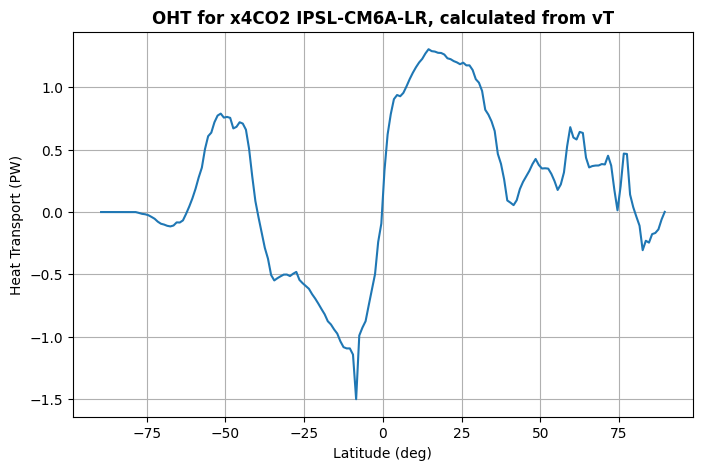

In [113]:
# 5. Checking if the depth-cumlat integral gives the heat transport

depth = lev_ipsl
lat = lat_ipsl

rho = 1025.0  # kg/m3
cp = 3985.0   # J/(kg·K)
R_earth = 6371000.0  # Earth radius in meters

# -----------------------------
# STEP 1: compute layer thicknesses
# -----------------------------
# Assuming depth array is midpoints
dz = np.diff(depth, prepend=0.0)  # shape: (depth,)

# Broadcast to match (depth, lat)
dz_2d = dz[:, np.newaxis]  # shape: (depth, 1)

# -----------------------------
# STEP 2: depth-integrated meridional flux
# -----------------------------
# Multiply by layer thickness and sum over depth, ignoring NaNs
vT_depth_integrated = np.nansum(vT_470_500_x4_ipsl_regr_zonal_v * dz_2d, axis=0)  # shape: (lat,)

# -----------------------------
# STEP 3: convert to meridional heat transport (Watts)
# -----------------------------
# Zonal length at each latitude
lat_rad = np.deg2rad(lat)
zonal_length = 2 * np.pi * R_earth * np.cos(lat_rad)  # meters

# Total meridional heat transport
Q_phi = vT_depth_integrated * rho * cp * zonal_length  # shape: (lat,)

# -----------------------------

plt.figure(figsize=(8,5))
plt.plot(lat, Q_phi / 1e15)
plt.xlabel('Latitude (deg)')
plt.ylabel('Heat Transport (PW)')
plt.title('OHT for x4CO2 IPSL-CM6A-LR, calculated from vT', fontweight = 'bold')
plt.grid()
#plt.legend()
plt.show()

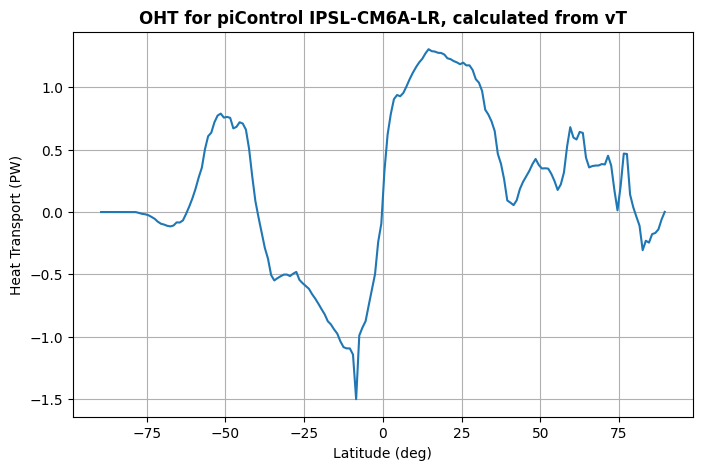

In [35]:
# 5. Checking if the depth-cumlat integral gives the heat transport

depth = lev_ipsl
lat = lat_ipsl

rho = 1025.0  # kg/m3
cp = 3985.0   # J/(kg·K)
R_earth = 6371000.0  # Earth radius in meters

# -----------------------------
# STEP 1: compute layer thicknesses
# -----------------------------
# Assuming depth array is midpoints
dz = np.diff(depth, prepend=0.0)  # shape: (depth,)

# Broadcast to match (depth, lat)
dz_2d = dz[:, np.newaxis]  # shape: (depth, 1)

# -----------------------------
# STEP 2: depth-integrated meridional flux
# -----------------------------
# Multiply by layer thickness and sum over depth, ignoring NaNs
vT_depth_integrated = np.nansum(vT_470_500_x4_ipsl_regr_zonal_v * dz_2d, axis=0)  # shape: (lat,)

# -----------------------------
# STEP 3: convert to meridional heat transport (Watts)
# -----------------------------
# Zonal length at each latitude
lat_rad = np.deg2rad(lat)
zonal_length = 2 * np.pi * R_earth * np.cos(lat_rad)  # meters

# Total meridional heat transport
Q_phi = vT_depth_integrated * rho * cp * zonal_length  # shape: (lat,)

# -----------------------------

plt.figure(figsize=(8,5))
plt.plot(lat, Q_phi / 1e15)
plt.xlabel('Latitude (deg)')
plt.ylabel('Heat Transport (PW)')
plt.title('OHT for piControl IPSL-CM6A-LR, calculated from vT', fontweight = 'bold')
plt.grid()
#plt.legend()
plt.show()

In [25]:
anom_ipsl = vT_470_500_x4_ipsl_regr_zonal_v - vT_pi_ipsl_regr_zonal_v

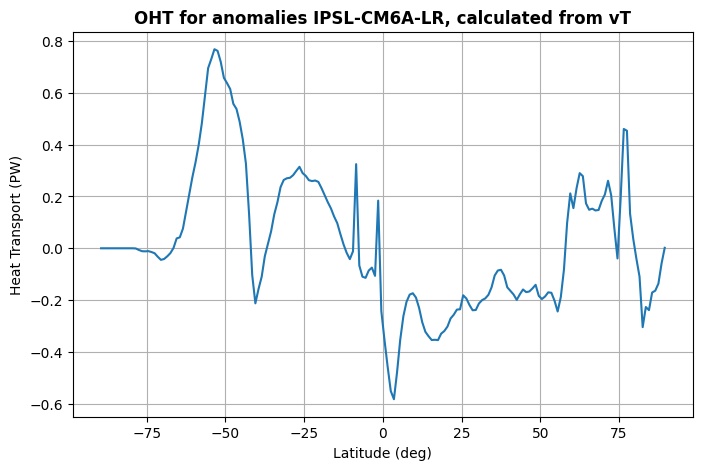

In [26]:
# 5. Checking if the depth-cumlat integral gives the heat transport

depth = lev_ipsl
lat = lat_ipsl

rho = 1025.0  # kg/m3
cp = 3985.0   # J/(kg·K)
R_earth = 6371000.0  # Earth radius in meters

# -----------------------------
# STEP 1: compute layer thicknesses
# -----------------------------
# Assuming depth array is midpoints
dz = np.diff(depth, prepend=0.0)  # shape: (depth,)

# Broadcast to match (depth, lat)
dz_2d = dz[:, np.newaxis]  # shape: (depth, 1)

# -----------------------------
# STEP 2: depth-integrated meridional flux
# -----------------------------
# Multiply by layer thickness and sum over depth, ignoring NaNs
vT_depth_integrated = np.nansum(anom_ipsl * dz_2d, axis=0)  # shape: (lat,)

# -----------------------------
# STEP 3: convert to meridional heat transport (Watts)
# -----------------------------
# Zonal length at each latitude
lat_rad = np.deg2rad(lat)
zonal_length = 2 * np.pi * R_earth * np.cos(lat_rad)  # meters

# Total meridional heat transport
Q_phi = vT_depth_integrated * rho * cp * zonal_length  # shape: (lat,)

# -----------------------------

plt.figure(figsize=(8,5))
plt.plot(lat, Q_phi / 1e15)
plt.xlabel('Latitude (deg)')
plt.ylabel('Heat Transport (PW)')
plt.title('OHT for anomalies IPSL-CM6A-LR, calculated from vT', fontweight = 'bold')
plt.grid()
#plt.legend()
plt.show()

# **C. CESM2**

## **1. Getting the data from NIRD**

### **1.1. meridional velocity (vo)**

In [27]:
experiments = ['piControl', 'abrupt-4xCO2']

vo_piControl_cesm2 = []
vo_x4CO2_cesm2 = []

for experiment in experiments:
            
    folder_path = f'/datalake/NS9560K/ESGF/CMIP6/CMIP/NCAR/CESM2/{experiment}/r1i1p1f1/Omon/vo/gn/latest/'

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks =({
        "time": 120,      
        "lev": 10,    
        "j": 100,
        "i": 100})) for file_name in file_names if file_name.endswith('.nc')]
    
    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(0, 999*12))
    
    if experiment == 'piControl':
    
        vo_piControl_cesm2 = ds
    else: 
        vo_x4CO2_cesm2 = ds 

### **1.2. potential temperature**

In [28]:
experiments = ['piControl', 'abrupt-4xCO2']

thetao_piControl_cesm2 = []
thetao_x4CO2_cesm2 = []

for experiment in experiments:
            
    folder_path = f'/datalake/NS9560K/ESGF/CMIP6/CMIP/NCAR/CESM2/{experiment}/r1i1p1f1/Omon/thetao/gn/latest/'

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks =({
        "time": 120,      
        "lev": 10,    
        "j": 100,
        "i": 100})) for file_name in file_names if file_name.endswith('.nc')]
    
    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(0, 999*12))

    if experiment == 'piControl':
    
        thetao_piControl_cesm2 = ds 
    else: 
        thetao_x4CO2_cesm2 = ds 

### **2. Calculating the total vT contours**

#### **2.1. Calculate v*T**

In [29]:
# Align first 
vo_piControl_cesm2, thetao_piControl_cesm2 = xr.align(vo_piControl_cesm2, thetao_piControl_cesm2, join="exact")
vo_x4CO2_cesm2, thetao_x4CO2_cesm2 = xr.align(vo_x4CO2_cesm2, thetao_x4CO2_cesm2.isel(time=slice(150*12, None)), join="exact")
#vo_x4CO2_cesm2, thetao_x4CO2_cesm2 = xr.align(vo_x4CO2_cesm2, thetao_x4CO2_cesm2, join="exact")

# Multiply the two variables
vT_pi_cesm2 = vo_piControl_cesm2["vo"] * thetao_piControl_cesm2["thetao"]
vT_x4_cesm2 = vo_x4CO2_cesm2["vo"] * thetao_x4CO2_cesm2["thetao"]

# Create a new Dataset including the shared variables (piControl)
vT_pi_cesm2_ds = xr.Dataset(
    data_vars={
        "vT": vT_pi_cesm2,
        "time_bnds": vo_piControl_cesm2["time_bnds"],
        "lat_bnds": vo_piControl_cesm2["lat_bnds"],
        "lon_bnds": vo_piControl_cesm2["lon_bnds"],
        "lev_bnds": vo_piControl_cesm2["lev_bnds"],
    },
    coords={
        "lat": vo_piControl_cesm2["lat"],
        "lev": vo_piControl_cesm2["lev"],
        "lon": vo_piControl_cesm2["lon"],
        "nlat": vo_piControl_cesm2["nlat"],
        "nlon": vo_piControl_cesm2["nlon"],
        "time": vo_piControl_cesm2["time"],
    },
    attrs=vo_piControl_cesm2.attrs  # optional: copy global attributes
)

# Create a new Dataset including the shared variables (x4CO2)
vT_x4_cesm2_ds = xr.Dataset(
    data_vars={
        "vT": vT_x4_cesm2,
        "time_bnds": vo_x4CO2_cesm2["time_bnds"],
        "lat_bnds": vo_x4CO2_cesm2["lat_bnds"],
        "lon_bnds": vo_x4CO2_cesm2["lon_bnds"],
        "lev_bnds": vo_x4CO2_cesm2["lev_bnds"],
    },
    coords={
        "lat": vo_x4CO2_cesm2["lat"],
        "lev": vo_x4CO2_cesm2["lev"],
        "lon": vo_x4CO2_cesm2["lon"],
        "nlat": vo_x4CO2_cesm2["nlat"],
        "nlon": vo_x4CO2_cesm2["nlon"],
        "time": vo_x4CO2_cesm2["time"],
    },
    attrs=vo_x4CO2_cesm2.attrs  # optional: copy global attributes
)

#### **2.2. Time average (try with yearly_avg now)**

**!!! we use years 502-532 for cesm2 picontrol to compare, to account for the shift in x4CO2 branching**

In [104]:
vT_pi_cesm2_ds = vT_pi_cesm2_ds.where(vT_pi_cesm2_ds != 0)
vT_x4_cesm2_ds = vT_x4_cesm2_ds.where(vT_x4_cesm2_ds != 0)

In [105]:
#piControl
vT_y_pi_cesm2 = yearly_avg_nan_proof(vT_pi_cesm2_ds) #first weighted average to make months -> years
vT_30y_pi_cesm2 = vT_y_pi_cesm2.isel(year=slice(502, 532)).mean(dim='year') #then total average
#vT_30y_pi_cesm2 = (vT_y_pi_cesm2.isel(year = slice(0, 10))).mean(dim='year') #then total average
#x4CO2
vT_y_x4_cesm2 = yearly_avg_nan_proof(vT_x4_cesm2_ds)
vT_470_500_x4_cesm2 = vT_y_x4_cesm2.isel(year=slice(470, 500)).mean(dim='year', skipna = True) 
#vT_470_500_x4_cesm2 = vT_y_x4_cesm2.mean(dim='year', skipna = True) 

#### **2.3. Regrid**

In [106]:
#piControl
vT_pi_cesm2_renamed = consistent_naming(vT_30y_pi_cesm2)
vT_pi_cesm2_regr = regrid_ocean_conserv(vT_pi_cesm2_renamed, "vT", None)
#x4CO2
vT_470_500_x4_cesm2_renamed = consistent_naming(vT_470_500_x4_cesm2)
vT_470_500_x4_cesm2_regr = regrid_ocean_conserv(vT_470_500_x4_cesm2_renamed, "vT", None)

In regrid_file
Regridding maker made
Regridding completed
In regrid_file
Regridding maker made
Regridding completed


#### **2.4. Zonal mean**

In [107]:
#piControl
vT_pi_cesm2_regr_zonal = vT_pi_cesm2_regr.mean(dim='lon', skipna = True)
#x4CO2
vT_470_500_x4_cesm2_regr_zonal = vT_470_500_x4_cesm2_regr.mean(dim='lon', skipna = True)

#### **2.5. Calculating the values and saving**

In [108]:
#vT_pi_cesm2_regr_zonal_v = vT_pi_cesm2_regr_zonal['vT'].values
vT_470_500_x4_cesm2_regr_zonal_v = vT_470_500_x4_cesm2_regr_zonal['vT'].values

#lat_cesm2 = vT_pi_cesm2_regr_zonal['lat'].values
#lev_cesm2 = vT_pi_cesm2_regr_zonal['lev'].values

In [38]:
save_dir = '/nird/home/chrikap/data/v_T_data/04.03.2026'

f_vT_pi_cesm2_regr_zonal_v = f"{save_dir}/vT_pi_cesm2_regr_zonal_v.npy"
f_vT_470_500_x4_cesm2_regr_zonal_v = f"{save_dir}/vT_470_500_x4_cesm2_regr_zonal_v.npy"

f_lat_cesm2 = f"{save_dir}/lat_cesm2.npy"
f_lev_cesm2 = f"{save_dir}/lev_cesm2.npy"

np.save(f_vT_pi_cesm2_regr_zonal_v, vT_pi_cesm2_regr_zonal_v)
np.save(f_vT_470_500_x4_cesm2_regr_zonal_v, vT_470_500_x4_cesm2_regr_zonal_v)

np.save(f_lat_cesm2, lat_cesm2)
np.save(f_lev_cesm2, lev_cesm2)

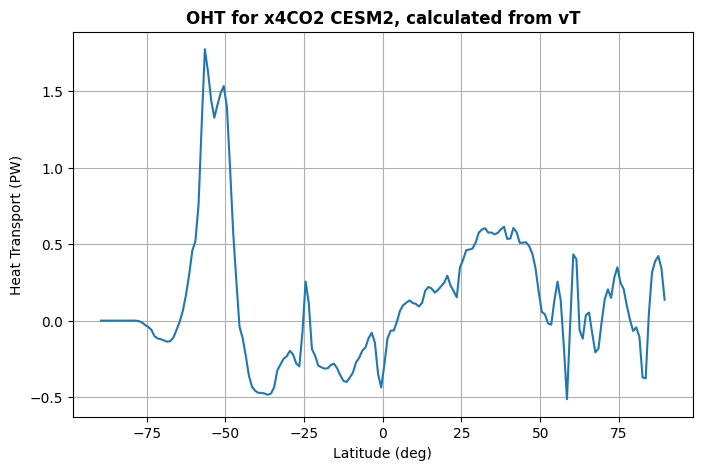

In [114]:
# 5. Checking if the depth-cumlat integral gives the heat transport

depth = lev_cesm2/100
lat = lat_cesm2

rho = 1025.0  # kg/m3
cp = 3985.0   # J/(kg·K)
R_earth = 6371000.0  # Earth radius in meters

# -----------------------------
# STEP 1: compute layer thicknesses
# -----------------------------
# Assuming depth array is midpoints
dz = np.diff(depth, prepend=0.0)  # shape: (depth,)
# Broadcast to match (depth, lat)
dz_2d = dz[:, np.newaxis]  # shape: (depth, 1)

# -----------------------------
# STEP 2: depth-integrated meridional flux
# -----------------------------
# Multiply by layer thickness and sum over depth, ignoring NaNs
vT_depth_integrated = np.nansum(vT_470_500_x4_cesm2_regr_zonal_v * dz_2d, axis=0)  # shape: (lat,)

# -----------------------------
# STEP 3: convert to meridional heat transport (Watts)
# -----------------------------
# Zonal length at each latitude
lat_rad = np.deg2rad(lat)
zonal_length = 2 * np.pi * R_earth * np.cos(lat_rad)  # meters

# Total meridional heat transport
Q_phi = vT_depth_integrated * rho * cp * zonal_length  # shape: (lat,)

# -----------------------------

plt.figure(figsize=(8,5))
plt.plot(lat, Q_phi / 1e15)
plt.xlabel('Latitude (deg)')
plt.ylabel('Heat Transport (PW)')
plt.title('OHT for x4CO2 CESM2, calculated from vT', fontweight = 'bold')
plt.grid()
#plt.legend()
plt.show()

In [40]:
anom_cesm2 = vT_470_500_x4_cesm2_regr_zonal_v - vT_pi_cesm2_regr_zonal_v

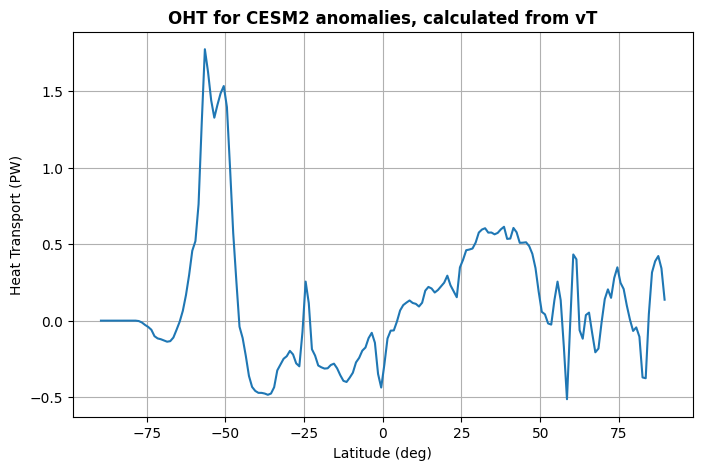

In [109]:
# 5. Checking if the depth-cumlat integral gives the heat transport

depth = lev_cesm2/100
lat = lat_cesm2

rho = 1025.0  # kg/m3
cp = 3985.0   # J/(kg·K)
R_earth = 6371000.0  # Earth radius in meters

# -----------------------------
# STEP 1: compute layer thicknesses
# -----------------------------
# Assuming depth array is midpoints
dz = np.diff(depth, prepend=0.0)  # shape: (depth,)

# Broadcast to match (depth, lat)
dz_2d = dz[:, np.newaxis]  # shape: (depth, 1)

# -----------------------------
# STEP 2: depth-integrated meridional flux
# -----------------------------
# Multiply by layer thickness and sum over depth, ignoring NaNs
vT_depth_integrated = np.nansum(vT_470_500_x4_cesm2_regr_zonal_v * dz_2d, axis=0)  # shape: (lat,)

# -----------------------------
# STEP 3: convert to meridional heat transport (Watts)
# -----------------------------
# Zonal length at each latitude
lat_rad = np.deg2rad(lat)
zonal_length = 2 * np.pi * R_earth * np.cos(lat_rad)  # meters

# Total meridional heat transport
Q_phi = vT_depth_integrated * rho * cp * zonal_length  # shape: (lat,)

# -----------------------------

plt.figure(figsize=(8,5))
plt.plot(lat, Q_phi / 1e15)
plt.xlabel('Latitude (deg)')
plt.ylabel('Heat Transport (PW)')
plt.title('OHT for CESM2 anomalies, calculated from vT', fontweight = 'bold')
plt.grid()
#plt.legend()
plt.show()

# **D. Plotting mean (vT) piControl**

In [21]:
os.chdir('/nird/home/chrikap/data/v_T_data/04.03.2026')

lat_noresm2 = np.load('lat_noresm2.npy')
lev_noresm2 = np.load('lev_noresm2.npy')
lat_ipsl = np.load('lat_ipsl.npy')
lev_ipsl = np.load('lev_ipsl.npy')
#lat_cesm2 = np.load('lat_cesm2.npy')
#lev_cesm2 = np.load('lev_cesm2.npy')


vT_pi_noresm2_regr_zonal_v = np.load('vT_pi_noresm2_regr_zonal_v.npy')
vT_470_500_x4_noresm2_regr_zonal_v = np.load('vT_470_500_x4_noresm2_regr_zonal_v.npy')

vT_pi_ipsl_regr_zonal_v = np.load('vT_pi_ipsl_regr_zonal_v.npy')
vT_470_500_x4_ipsl_regr_zonal_v = np.load('vT_470_500_x4_ipsl_regr_zonal_v.npy')

#vT_pi_cesm2_regr_zonal_v = np.load('vT_pi_cesm2_regr_zonal_v.npy')
#vT_470_500_x4_cesm2_regr_zonal_v = np.load('vT_470_500_x4_cesm2_regr_zonal_v.npy')

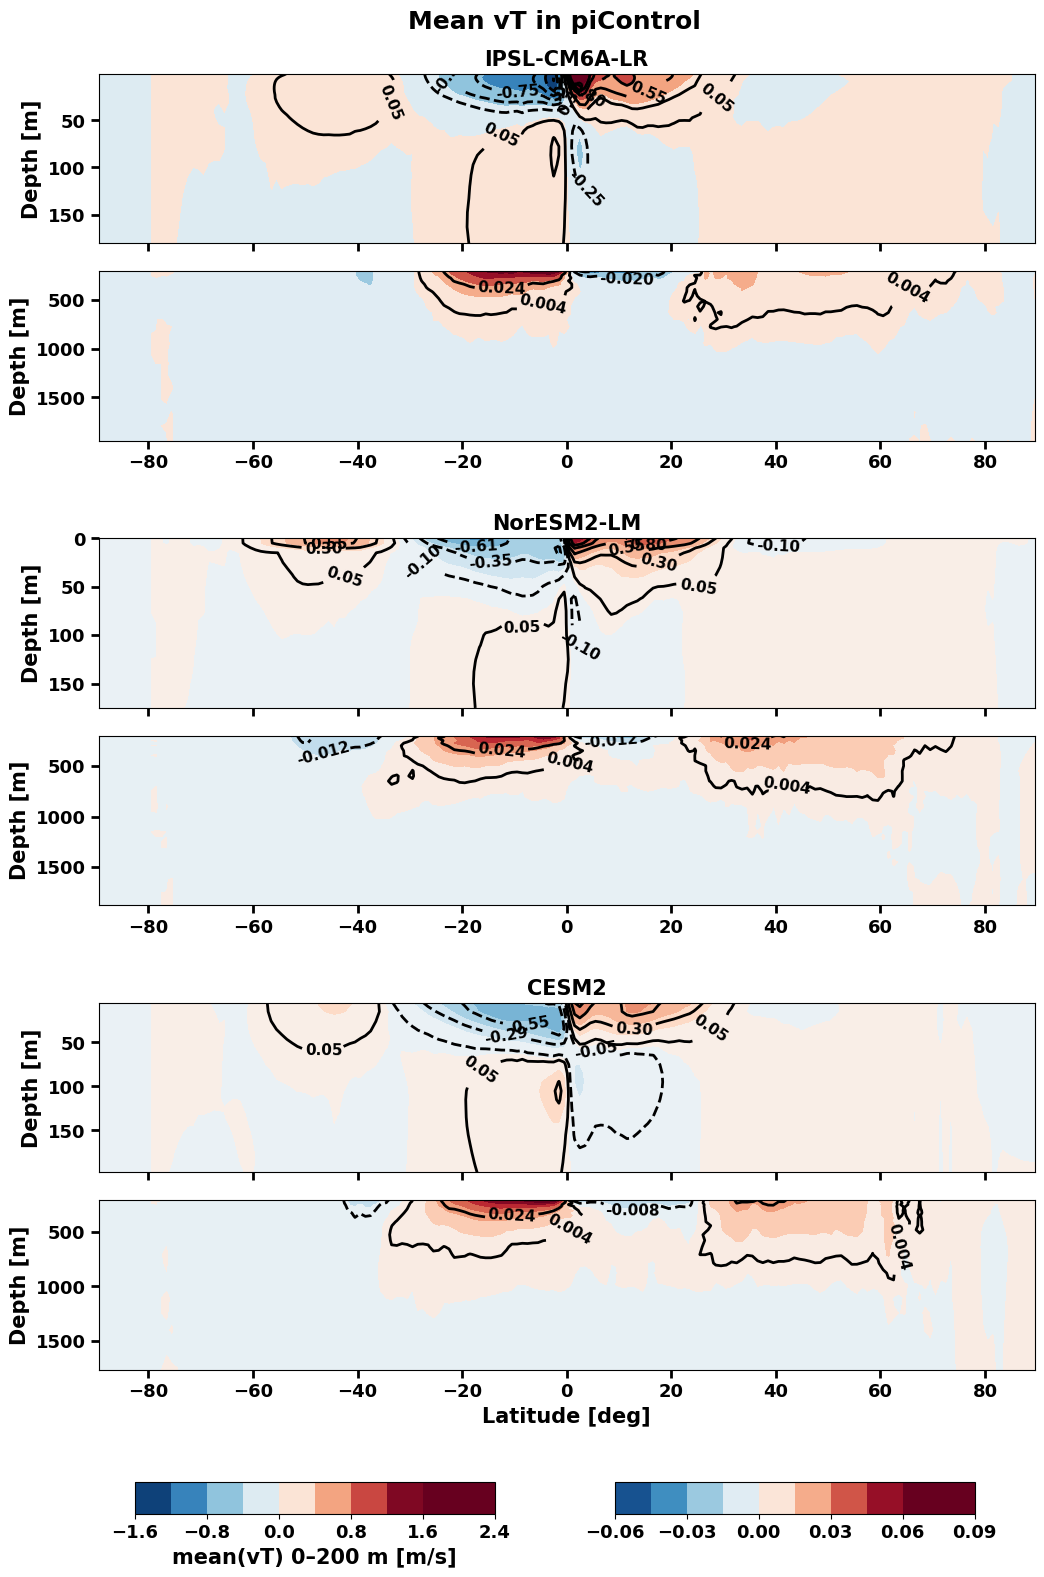

In [43]:
data_piControl_list_200 = [vT_pi_ipsl_regr_zonal_v[0:30, :],
                           vT_pi_noresm2_regr_zonal_v[0:18, :],
                           vT_pi_cesm2_regr_zonal_v[0:20]]
data_piControl_list_2000 = [vT_pi_ipsl_regr_zonal_v[30:54, :],
                            vT_pi_noresm2_regr_zonal_v[18:50, :],
                            vT_pi_cesm2_regr_zonal_v[20:45]]

titles = ["IPSL-CM6A-LR", "NorESM2-LM", "CESM2"]

fig = plt.figure(figsize=(12,16))

gs = fig.add_gridspec(
    nrows=8, ncols=1,
    height_ratios=[1,1,0.25,1,1,0.25,1,1]
)

row_positions = [0,1,3,4,6,7]

# ranges
vmin_shallow, vmax_shallow = -1.5, 1.5
vmin_deep, vmax_deep = -0.06, 0.06

target_levels_shallow = np.arange(-1.5, 1.51, 0.05)
target_levels_deep = np.arange(-0.04, 0.041, 0.004)

panel = 0
im_shallow = None
im_deep = None

for i, model in enumerate(titles):
    for j, data_list in enumerate([data_piControl_list_200, data_piControl_list_2000]):

        data = data_list[i]

        # coordinates
        if model == "NorESM2-LM":
            lat = lat_noresm2
            lev = lev_noresm2[0:18] if j==0 else lev_noresm2[18:50]
        elif model == "CESM2":
            lat = lat_cesm2
            lev = lev_cesm2/100
            lev = lev[0:20] if j==0 else lev[20:45]
        else:
            lat = lat_ipsl
            lev = lev_ipsl[0:30] if j==0 else lev_ipsl[30:54]

        ax = fig.add_subplot(gs[row_positions[panel],0])

        if j == 0:
            ax.set_xticklabels([])

        ax.tick_params(axis='both', labelsize=13)

        # make tick lines bold for both axes
        ax.tick_params(axis='both', which='major', width=2, length=6)   # major ticks
        ax.tick_params(axis='both', which='minor', width=1, length=4)   # minor ticks (optional)

        # make tick labels bold
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontweight('bold')

        # choose range depending on depth slice
        if j == 0:
            im = ax.contourf(lat, lev, data,
                             levels=10,
                             cmap="RdBu_r",
                             vmin=vmin_shallow,
                             vmax=vmax_shallow)
            if im_shallow is None:
                im_shallow = im
        else:
            im = ax.contourf(lat, lev, data,
                             levels=10,
                             cmap="RdBu_r",
                             vmin=vmin_deep,
                             vmax=vmax_deep)
            if im_deep is None:
                im_deep = im

        # contour lines
        levels = np.unique(nearest_levels(data, target_levels_shallow if j==0 else target_levels_deep))
        neg_levels = levels[levels < 0]
        pos_levels = levels[levels > 0]

        pi_neg = ax.contour(lat, lev, data,
                            levels=neg_levels[::5],
                            colors='k',
                            linestyles='dashed',
                            linewidths=2)
        pi_pos = ax.contour(lat, lev, data,
                            levels=pos_levels[::5],
                            colors='k',
                            linestyles='solid',
                            linewidths=2)

        # contour labels bold and size 11
        fmt = "%.2f" if j==0 else "%.3f"
        labels_neg = ax.clabel(pi_neg, inline=True, fmt=fmt, fontsize=11)
        labels_pos = ax.clabel(pi_pos, inline=True, fmt=fmt, fontsize=11)
        for txt in labels_neg + labels_pos:
            txt.set_fontweight('bold')

        if j == 0:
            ax.set_title(model, fontweight='bold', fontsize=15)

        ax.invert_yaxis()
        ax.set_ylabel("Depth [m]", fontweight="bold", fontsize=15)

        if panel == 5:
            ax.set_xlabel("Latitude [deg]", fontweight="bold", fontsize=15)

        panel += 1

# ----- COLORBARS AT BOTTOM -----

# shallow
cbar_ax1 = fig.add_axes([0.15, 0.06, 0.3, 0.02])
cbar1 = fig.colorbar(im_shallow, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("mean(vT) 0–200 m [m/s]", fontsize=15, fontweight='bold')
cbar1.ax.tick_params(labelsize=13)  # make numbers bigger

# make numbers bold
for t in cbar1.ax.get_xticklabels():
    t.set_fontweight('bold')

# deep
cbar_ax2 = fig.add_axes([0.55, 0.06, 0.3, 0.02])
cbar2 = fig.colorbar(im_deep, cax=cbar_ax2, orientation="horizontal")

# divide tick labels by 100
formatter = FuncFormatter(lambda x, pos: f"{x*100:.2f}")
#cbar2.ax.xaxis.set_major_formatter(formatter)
#cbar2.set_label("mean(vT) 200–2000 m [m/s] ×10$^{-2}$", fontsize=15, fontweight='bold')
cbar2.ax.tick_params(labelsize=13)  # bigger numbers
for t in cbar2.ax.get_xticklabels():
    t.set_fontweight('bold')
fig.suptitle("Mean vT in piControl", fontsize=18, weight='bold', y=1)

plt.subplots_adjust(
    top=0.96,
    bottom=0.15,
    left=0.12,
    right=0.9
)

plt.show()

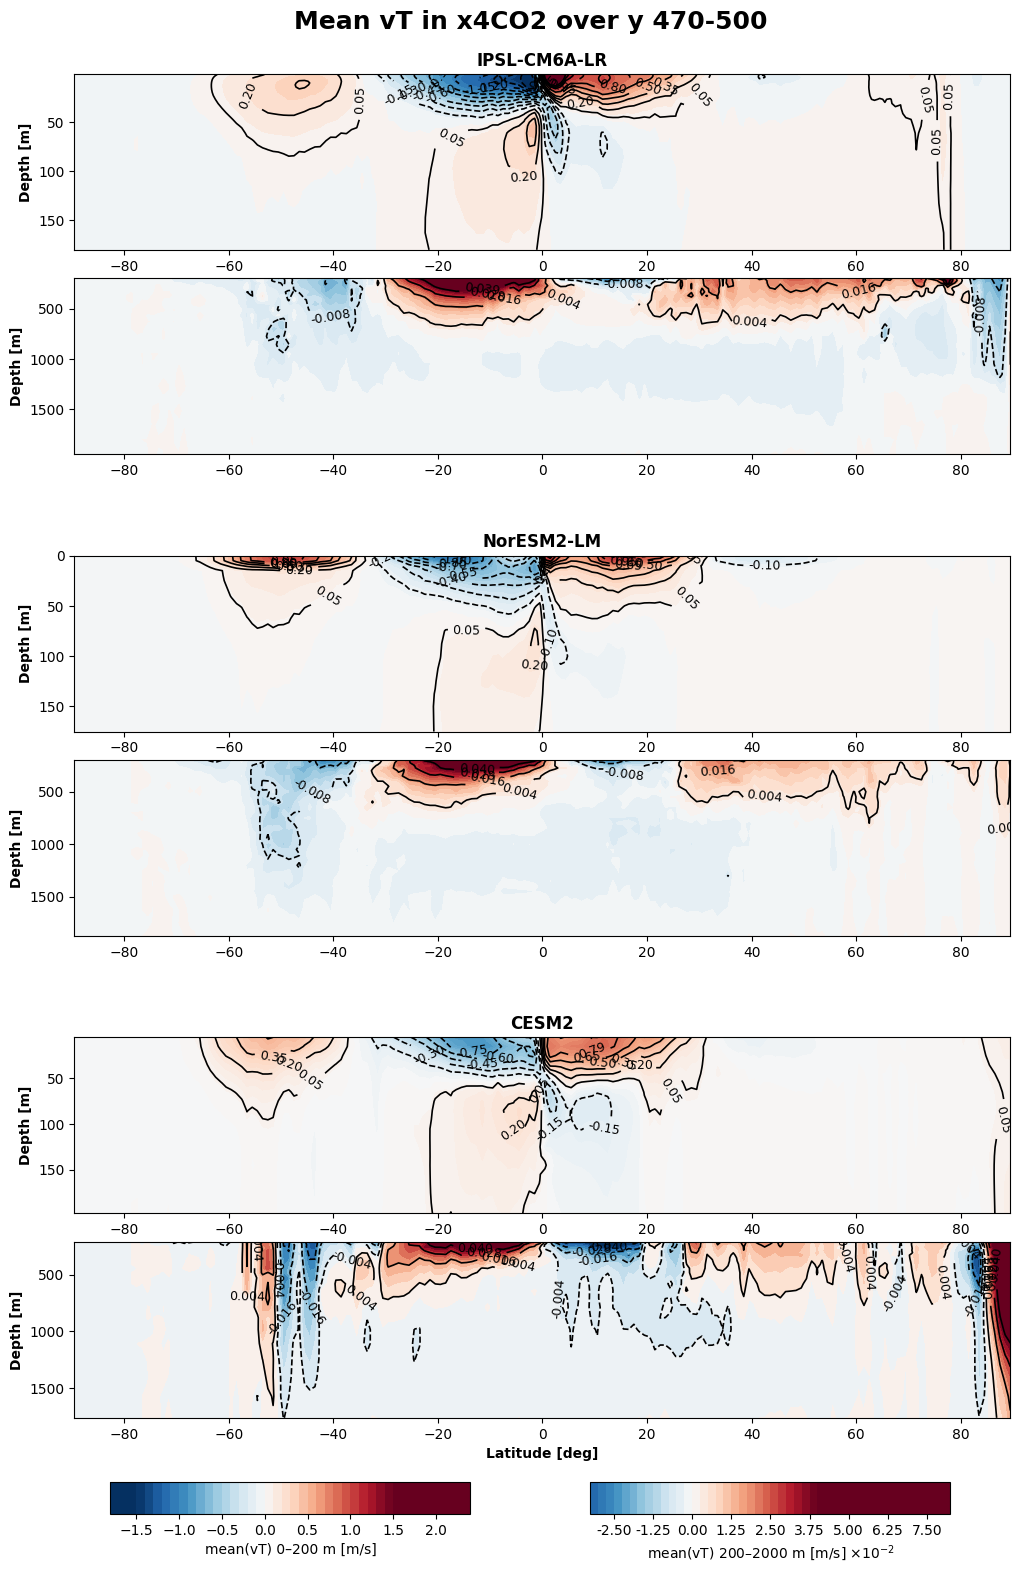

In [61]:
#data_x4CO2_list = [vT_470_500_x4_ipsl_regr_zonal_v[0:24, :], vT_470_500_x4_noresm2_regr_zonal_v[0:13, :], vT_470_500_x4_cesm2_regr_zonal_v[0:10, :]] #up to 100m
data_x4CO2_list_200 = [vT_470_500_x4_ipsl_regr_zonal_v[0:30, :], vT_470_500_x4_noresm2_regr_zonal_v[0:18, :], vT_470_500_x4_cesm2_regr_zonal_v[0:20, :]] #up to 200m
#data_x4CO2_list = [vT_470_500_x4_ipsl_regr_zonal_v[0:39, :], vT_470_500_x4_noresm2_regr_zonal_v[0:26, :], vT_470_500_x4_cesm2_regr_zonal_v[0:33, :]] #up to 500m
data_x4CO2_list_2000 = [vT_470_500_x4_ipsl_regr_zonal_v[30:54, :], vT_470_500_x4_noresm2_regr_zonal_v[18:50, :], vT_470_500_x4_cesm2_regr_zonal_v[20:45, :]] #up to 500m

fig = plt.figure(figsize=(12,16))

gs = fig.add_gridspec(
    nrows=8, ncols=1,
    height_ratios=[1,1,0.25,1,1,0.25,1,1]
)

row_positions = [0,1,3,4,6,7]

# ranges
vmin_shallow, vmax_shallow = -1.5, 1.5
vmin_deep, vmax_deep = -0.04, 0.04

target_levels_shallow = np.arange(-1.5, 1.51, 0.05)
target_levels_deep = np.arange(-0.04, 0.041, 0.004)
panel = 0
im_shallow = None
im_deep = None

for i, model in enumerate(titles):

    for j, data_list in enumerate([data_x4CO2_list_200,
                                   data_x4CO2_list_2000]):

        data = data_list[i]

        # coordinates
        if model == "NorESM2-LM":
            lat = lat_noresm2
            lev = lev_noresm2[0:18] if j==0 else lev_noresm2[18:50]

        elif model == "CESM2":
            lat = lat_cesm2
            lev = lev_cesm2/100
            lev = lev[0:20] if j==0 else lev[20:45]

        else:
            lat = lat_ipsl
            lev = lev_ipsl[0:30] if j==0 else lev_ipsl[30:54]

        ax = fig.add_subplot(gs[row_positions[panel],0])

        # choose range depending on depth slice
        if j == 0:
            im = ax.contourf(
                lat, lev, data,
                levels=45,
                cmap="RdBu_r",
                vmin=vmin_shallow,
                vmax=vmax_shallow
            )
            if im_shallow is None:
                im_shallow = im

        else:
            im = ax.contourf(
                lat, lev, data,
                levels=45,
                cmap="RdBu_r",
                vmin=vmin_deep,
                vmax=vmax_deep
            )
            if im_deep is None:
                im_deep = im

        # contour lines
        if j == 0:
            target_levels = target_levels_shallow
        else:
            target_levels = target_levels_deep
        
        levels = np.unique(nearest_levels(data, target_levels))
        neg_levels = levels[levels < 0]
        pos_levels = levels[levels > 0]
        
        pi_neg = ax.contour(
            lat, lev, data,
            levels=neg_levels[::3],
            colors='k',
            linestyles='dashed',
            linewidths=1.2
        )
        
        pi_pos = ax.contour(
            lat, lev, data,
            levels=pos_levels[::3],
            colors='k',
            linestyles='solid',
            linewidths=1.2
        )
        
        if j == 0:
            fmt = "%.2f"   # 2 significant digits
        else:
            fmt = "%.3f"   # 3 significant digits
        
        ax.clabel(pi_neg, inline=True, fmt=fmt, fontsize=9)
        ax.clabel(pi_pos, inline=True, fmt=fmt, fontsize=9)
        
        if j == 0:
            ax.set_title(model, fontweight='bold')

        ax.invert_yaxis()
        ax.set_ylabel("Depth [m]", fontweight="bold")

        if panel == 5:
            ax.set_xlabel("Latitude [deg]", fontweight="bold")

        panel += 1

# ----- COLORBARS AT BOTTOM -----

# shallow
cbar_ax1 = fig.add_axes([0.15, 0.06, 0.3, 0.02])
cbar1 = fig.colorbar(im_shallow, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("mean(vT) 0–200 m [m/s]")

# deep
cbar_ax2 = fig.add_axes([0.55, 0.06, 0.3, 0.02])

cbar2 = fig.colorbar(im_deep, cax=cbar_ax2, orientation="horizontal")

# divide tick labels by 100
formatter = FuncFormatter(lambda x, pos: f"{x*100:.2f}")
cbar2.ax.xaxis.set_major_formatter(formatter)

cbar2.set_label("mean(vT) 200–2000 m [m/s] ×10$^{-2}$")

fig.suptitle("Mean vT in x4CO2 over y 470-500", fontsize=18, weight='bold', y=1)

plt.subplots_adjust(
    top=0.96,
    bottom=0.12,
    left=0.12,
    right=0.9
)

plt.show()

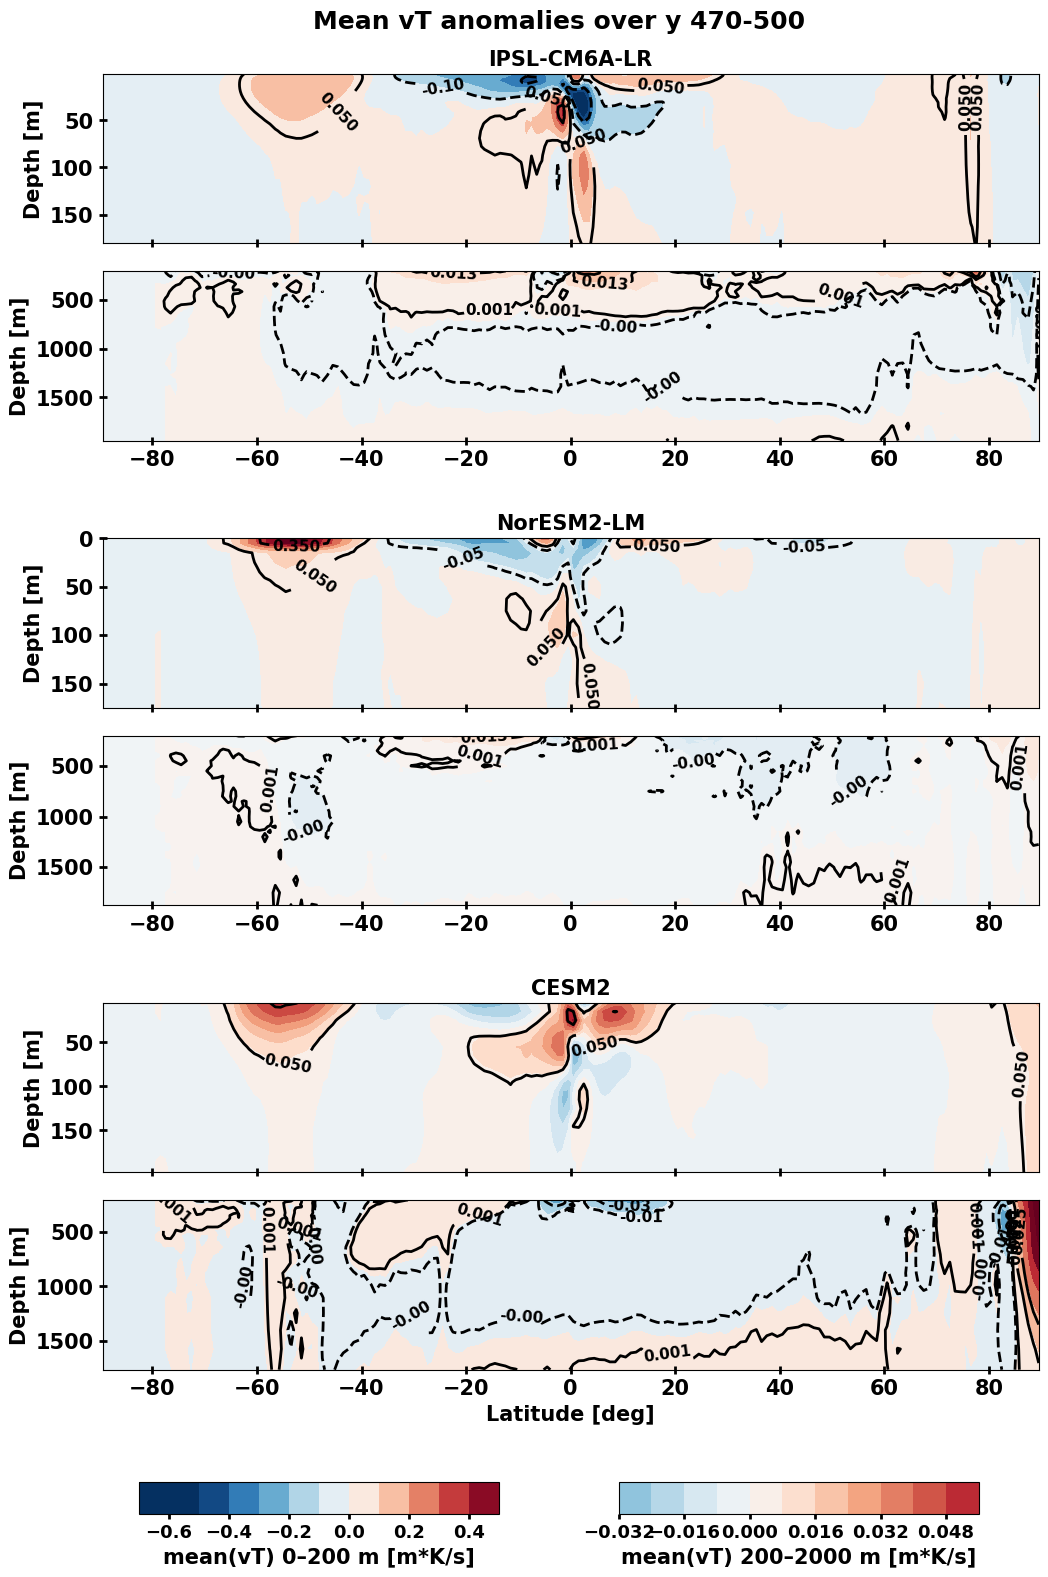

In [44]:
titles = ["IPSL-CM6A-LR", "NorESM2-LM", "CESM2"]

data_anom_list_200 = [
    (vT_470_500_x4_ipsl_regr_zonal_v - vT_pi_ipsl_regr_zonal_v)[0:30, :],
    (vT_470_500_x4_noresm2_regr_zonal_v - vT_pi_noresm2_regr_zonal_v)[0:18, :],
    (vT_470_500_x4_cesm2_regr_zonal_v - vT_pi_cesm2_regr_zonal_v)[0:20, :]
]

data_anom_list_2000 = [
    (vT_470_500_x4_ipsl_regr_zonal_v - vT_pi_ipsl_regr_zonal_v)[30:54, :],
    (vT_470_500_x4_noresm2_regr_zonal_v - vT_pi_noresm2_regr_zonal_v)[18:50, :],
    (vT_470_500_x4_cesm2_regr_zonal_v - vT_pi_cesm2_regr_zonal_v)[20:45, :]
]

fig = plt.figure(figsize=(12,16))

gs = fig.add_gridspec(
    nrows=8, ncols=1,
    height_ratios=[1,1,0.25,1,1,0.25,1,1]
)

row_positions = [0,1,3,4,6,7]

# ---- Ranges (keep as requested) ----
vmin_shallow, vmax_shallow = -.5, .5
vmin_deep, vmax_deep = -.07, .07

target_levels_shallow = np.arange(-.4, .41, 0.05)
target_levels_deep = np.arange(-0.025, 0.0251, 0.002)

panel = 0
im_shallow = None
im_deep = None

for i, model in enumerate(titles):

    for j, data_list in enumerate([data_anom_list_200, data_anom_list_2000]):

        data = data_list[i]

        # ---- coordinates ----
        if model == "NorESM2-LM":
            lat = lat_noresm2
            lev = lev_noresm2[0:18] if j==0 else lev_noresm2[18:50]
        elif model == "CESM2":
            lat = lat_cesm2
            lev = lev_cesm2 / 100
            lev = lev[0:20] if j==0 else lev[20:45]
        else:
            lat = lat_ipsl
            lev = lev_ipsl[0:30] if j==0 else lev_ipsl[30:54]

        ax = fig.add_subplot(gs[row_positions[panel],0])

        if j == 0:
            ax.set_xticklabels([])

        ax.tick_params(axis='both', labelsize=13)

        # make tick lines bold for both axes
        ax.tick_params(axis='both', which='major', width=2, length=6)   # major ticks
        ax.tick_params(axis='both', which='minor', width=1, length=4)   # minor ticks (optional)

        # make tick labels bold
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontweight('bold')

        # ---- Filled contour ----
        if j == 0:
            im = ax.contourf(
                lat, lev, data,
                levels=10,
                cmap="RdBu_r",
                vmin=vmin_shallow,
                vmax=vmax_shallow
            )
            if im_shallow is None:
                im_shallow = im
        else:
            im = ax.contourf(
                lat, lev, data,
                levels=10,
                cmap="RdBu_r",
                vmin=vmin_deep,
                vmax=vmax_deep
            )
            if im_deep is None:
                im_deep = im

        # ---- Contour lines ----
        levels = np.unique(nearest_levels(data, target_levels_shallow if j==0 else target_levels_deep))
        neg_levels = levels[levels < 0]
        pos_levels = levels[levels > 0]

        pi_neg = ax.contour(
            lat, lev, data,
            levels=neg_levels[::6],
            colors='k',
            linestyles='dashed',
            linewidths=2
        )
        pi_pos = ax.contour(
            lat, lev, data,
            levels=pos_levels[::6],
            colors='k',
            linestyles='solid',
            linewidths=2
        )

        # ---- Contour labels ----
        labels_neg = ax.clabel(pi_neg, inline=True, fmt="%1.2f", fontsize=11)
        labels_pos = ax.clabel(pi_pos, inline=True, fmt="%1.3f", fontsize=11)
        for txt in labels_neg + labels_pos:
            txt.set_fontweight('bold')

        # ---- Titles ----
        if j == 0:
            ax.set_title(model, fontweight='bold', fontsize=15)

        # ---- Axes formatting ----
        ax.invert_yaxis()
        ax.set_ylabel("Depth [m]", fontsize=15, fontweight="bold")
        ax.tick_params(axis='both', which='major', labelsize=15, width=2, length=6, direction='inout', colors='black')

        # ---- Hide top panel x-axis numbers ----
        if panel ==5:  # first panel of each model
            ax.set_xlabel("Latitude [deg]", fontsize=15, fontweight='bold')

        panel += 1

# ----- COLORBARS -----
# Shallow
cbar_ax1 = fig.add_axes([0.15, 0.06, 0.3, 0.02])
cbar1 = fig.colorbar(im_shallow, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("mean(vT) 0–200 m [m*K/s]", fontsize=15, fontweight='bold')
cbar1.ax.tick_params(labelsize=13, width=2)
for t in cbar1.ax.get_xticklabels():
    t.set_fontweight('bold')

# Deep
cbar_ax2 = fig.add_axes([0.55, 0.06, 0.3, 0.02])
cbar2 = fig.colorbar(im_deep, cax=cbar_ax2, orientation="horizontal")
#formatter = FuncFormatter(lambda x, pos: f"{x*100:.2f}")
#cbar2.ax.xaxis.set_major_formatter(formatter)
cbar2.set_label("mean(vT) 200–2000 m [m*K/s]", fontsize=15, fontweight='bold')
cbar2.ax.tick_params(labelsize=13, width=2)
for t in cbar2.ax.get_xticklabels():
    t.set_fontweight('bold')

# ---- Super title ----
fig.suptitle("Mean vT anomalies over y 470-500", fontsize=18, weight='bold', y=1)

plt.subplots_adjust(
    top=0.96,
    bottom=0.15,
    left=0.12,
    right=0.9
)

plt.show()